In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import scipy.io
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from scipy.optimize import nnls
import sys      


In [2]:
X_train_rough = np.load('data/X_train_rough.npy')
X_train_np = np.load('data/X_train_np.npy')
y_train_np = np.load('data/y_train_np.npy')
labels_list = np.load('data/labels_list.npy', allow_pickle=True)


In [3]:
plt.ioff()
wavelengths = np.linspace(1550, 1565, 1500)

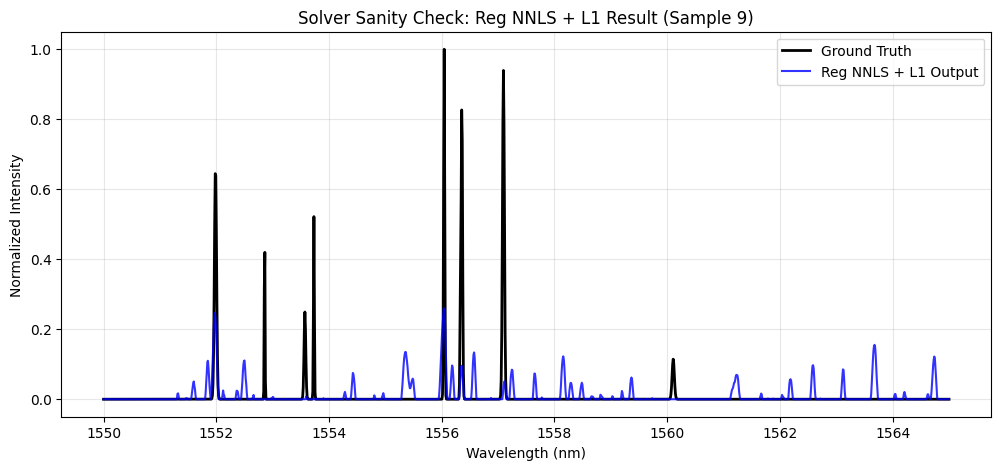

In [6]:
# plot one graph to see
sample_idx = 9
plt.figure(figsize=(12, 5))
plt.plot(wavelengths, y_train_np[sample_idx], label="Ground Truth", color="black", linewidth=2)
plt.plot(wavelengths, X_train_rough[sample_idx], label="Reg NNLS + L1 Output", color="blue", alpha=0.8)
plt.title(f"Solver Sanity Check: Reg NNLS + L1 Result (Sample {sample_idx})")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Normalized Intensity")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show(block=True)



In [7]:
# add classification network

class ClasificationNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        self.layer1 = nn.Linear(25, 64)
        self.layer2 = nn.Linear(64, 64)
        self.layer3 = nn.Linear(64, 2)

        # activation functions
        self.ReLU = nn.ReLU()

    def forward(self, x):
        x = self.layer1(x)
        x = self.ReLU(x)

        x = self.layer2(x)
        x = self.ReLU(x)

        x = self.layer3(x)

        return x



In [9]:
classificationModel = ClasificationNetwork()
classificationModel.load_state_dict(torch.load('data/classification_model.pth'))
classificationModel.eval()


ClasificationNetwork(
  (layer1): Linear(in_features=25, out_features=64, bias=True)
  (layer2): Linear(in_features=64, out_features=64, bias=True)
  (layer3): Linear(in_features=64, out_features=2, bias=True)
  (ReLU): ReLU()
)

In [12]:
# Calculate and save normalization statistics
mean = X_train_np.mean(axis=0)
std = X_train_np.std(axis=0)

# Save these for later use
np.save('data/normalization_mean.npy', mean)
np.save('data/normalization_std.npy', std)

print(f"Mean shape: {mean.shape}")
print(f"Std shape: {std.shape}")

Mean shape: (25,)
Std shape: (25,)


In [13]:
# Load normalization statistics
mean = np.load('data/normalization_mean.npy')
std = np.load('data/normalization_std.npy')

# Get multiple samples
samples = X_train_np[:10]  # First 10 samples

# Normalize the samples using the SAME mean and std as training
samples_normalized = (samples - mean) / std

# Convert to tensor
samples_tensor = torch.from_numpy(samples_normalized).float()  # Shape: (10, 25)

# Make predictions
with torch.no_grad():
    outputs = classificationModel(samples_tensor)
    probabilities = torch.softmax(outputs, dim=1)
    predicted_classes = torch.argmax(probabilities, dim=1)

print(f"Predicted classes: {predicted_classes.numpy()}")
print(f"Probabilities:\n{probabilities}")

Predicted classes: [0 0 1 1 1 1 0 0 1 0]
Probabilities:
tensor([[9.9637e-01, 3.6287e-03],
        [9.9419e-01, 5.8119e-03],
        [3.6214e-04, 9.9964e-01],
        [3.3812e-06, 1.0000e+00],
        [1.0891e-04, 9.9989e-01],
        [7.8297e-06, 9.9999e-01],
        [9.9249e-01, 7.5054e-03],
        [9.9507e-01, 4.9344e-03],
        [7.1746e-06, 9.9999e-01],
        [9.9423e-01, 5.7658e-03]])


NameError: name 'labels_ints_list' is not defined